In [1]:
# Импорты
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', '{:.5f}'.format)

In [2]:
# Загрузка S&P500 и EUR/USD
df_sp500 = pd.read_csv('data/processed/sp500.csv', parse_dates=['Date'], index_col='Date')
df_fx = pd.read_csv('data/processed/eurusd.csv', parse_dates=['Date'], index_col='Date')

In [3]:
# Лог-возвраты
df_sp500['return'] = np.log(df_sp500['price']).diff()
df_fx['return'] = np.log(df_fx['price']).diff()

# Скользящие средние и волатильность
for ma in [7, 14, 52]:
    df_sp500[f'MA_{ma}'] = df_sp500['price'].rolling(ma).mean()
    df_fx[f'MA_{ma}'] = df_fx['price'].rolling(ma).mean()

# Скользящая волатильность
for w in [7, 14, 52]:
    df_sp500[f'vol_{w}'] = df_sp500['return'].rolling(w).std()
    df_fx[f'vol_{w}'] = df_fx['return'].rolling(w).std()

In [4]:
# Проверка стационарности через ADF
def adf_test(series, name='Series'):
    result = adfuller(series.dropna())
    print(f'ADF Test for {name}:')
    print(f'ADF Statistic: {result[0]:.5f}')
    print(f'p-value: {result[1]:.5f}')
    print('Stationary' if result[1] < 0.05 else 'Non-stationary')

# Применяем к returns
df_sp500['return'] = df_sp500['price'].pct_change()
df_fx['return'] = df_fx['price'].pct_change()

adf_test(df_sp500['return'], 'S&P500 Return')
adf_test(df_fx['return'], 'EUR/USD Return')

ADF Test for S&P500 Return:
ADF Statistic: -15.46032
p-value: 0.00000
Stationary
ADF Test for EUR/USD Return:
ADF Statistic: -28.21253
p-value: 0.00000
Stationary


In [6]:
# S&P500 Price + MA
fig = go.Figure()
fig.add_trace(go.Scatter(x=df_sp500.index, y=df_sp500['price'], mode='lines', name='Price'))
for ma in [7, 14, 52]:
    fig.add_trace(go.Scatter(x=df_sp500.index, y=df_sp500[f'MA_{ma}'], mode='lines', name=f'MA_{ma}'))
fig.update_layout(title='S&P500 Price with Moving Averages', xaxis_title='Date', yaxis_title='Price')
fig.show()

# EUR/USD Price + MA
fig = go.Figure()
fig.add_trace(go.Scatter(x=df_fx.index, y=df_fx['price'], mode='lines', name='Price'))
for ma in [7, 14, 52]:
    fig.add_trace(go.Scatter(x=df_fx.index, y=df_fx[f'MA_{ma}'], mode='lines', name=f'MA_{ma}'))
fig.update_layout(title='EUR/USD Price with Moving Averages', xaxis_title='Date', yaxis_title='Price')
fig.show()

In [7]:
# S&P500 Volatility
fig = go.Figure()
for w in [7, 14, 52]:
    fig.add_trace(go.Scatter(x=df_sp500.index, y=df_sp500[f'vol_{w}'], mode='lines', name=f'Vol_{w}'))
fig.update_layout(title='S&P500 Rolling Volatility', xaxis_title='Date', yaxis_title='Volatility')
fig.show()

# EUR/USD Volatility
fig = go.Figure()
for w in [7, 14, 52]:
    fig.add_trace(go.Scatter(x=df_fx.index, y=df_fx[f'vol_{w}'], mode='lines', name=f'Vol_{w}'))
fig.update_layout(title='EUR/USD Rolling Volatility', xaxis_title='Date', yaxis_title='Volatility')
fig.show()

<Figure size 1200x400 with 0 Axes>

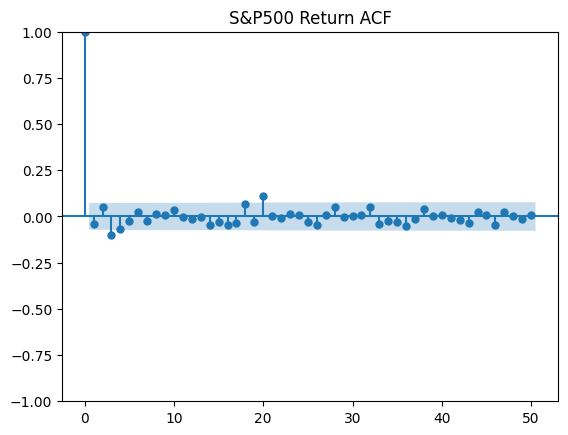

<Figure size 1200x400 with 0 Axes>

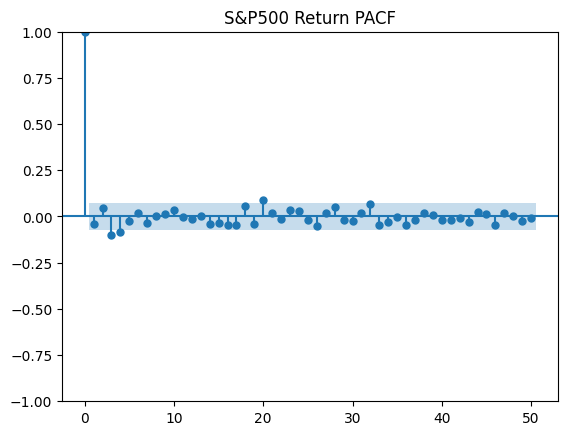

<Figure size 1200x400 with 0 Axes>

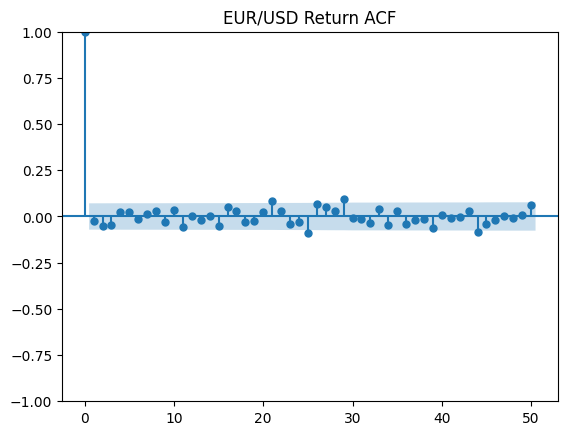

<Figure size 1200x400 with 0 Axes>

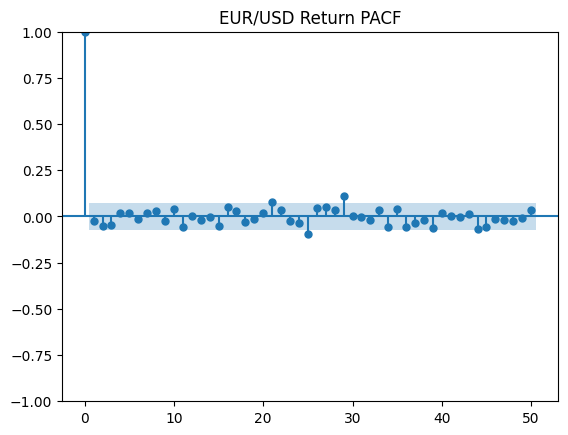

In [8]:
# S&P500 Returns
plt.figure(figsize=(12,4))
plot_acf(df_sp500['return'].dropna(), lags=50)
plt.title('S&P500 Return ACF')
plt.show()

plt.figure(figsize=(12,4))
plot_pacf(df_sp500['return'].dropna(), lags=50)
plt.title('S&P500 Return PACF')
plt.show()

# EUR/USD Returns
plt.figure(figsize=(12,4))
plot_acf(df_fx['return'].dropna(), lags=50)
plt.title('EUR/USD Return ACF')
plt.show()

plt.figure(figsize=(12,4))
plot_pacf(df_fx['return'].dropna(), lags=50)
plt.title('EUR/USD Return PACF')
plt.show()

In [9]:
def adf_test(series, name='Series'):
    result = adfuller(series.dropna())
    print(f'ADF Test for {name}:')
    print(f'ADF Statistic: {result[0]:.5f}')
    print(f'p-value: {result[1]:.5f}')
    print('Stationary' if result[1] < 0.05 else 'Non-stationary')

adf_test(df_sp500['return'], 'S&P500 Return')
adf_test(df_fx['return'], 'EUR/USD Return')

ADF Test for S&P500 Return:
ADF Statistic: -15.46032
p-value: 0.00000
Stationary
ADF Test for EUR/USD Return:
ADF Statistic: -28.21253
p-value: 0.00000
Stationary


In [10]:
# Загружаем сохранённые предсказания
df_preds = pd.read_csv("results/predictions/sp500_predictions.csv", index_col=0, parse_dates=True)

# Объединяем train + test для визуализации
# Предполагаем, что df_sp500 уже есть с колонкой 'return'
df_train_test = df_preds.copy()

# График фактических цен / return
fig = go.Figure()
fig.add_trace(go.Scatter(x=df_train_test.index, y=df_train_test['return'], 
                         mode='lines', name='Actual Return', line=dict(color='black')))

# Добавляем прогнозы всех моделей
model_cols = ['naive', 'garch', 'xgboost', 'mlp']
colors = ['blue', 'green', 'orange', 'red']

for col, color in zip(model_cols, colors):
    fig.add_trace(go.Scatter(x=df_train_test.index, y=df_train_test[col], 
                             mode='lines', name=f'Prediction ({col})', line=dict(color=color)))

# Опционально: нарисовать regimes фоном
for regime_val, color in zip([0,1], ['rgba(0,0,255,0.1)','rgba(255,0,0,0.1)']):
    mask = df_train_test['regime'] == regime_val
    if mask.any():
        fig.add_trace(go.Scatter(
            x=df_train_test.index[mask],
            y=[df_train_test['return'].min()]*mask.sum(),
            fill='tonexty',
            mode='none',
            fillcolor=color,
            name=f"Regime {regime_val}"
        ))

fig.update_layout(title="S&P500 Returns: Actual vs Predictions (Train + Test)",
                  xaxis_title="Date", yaxis_title="Return",
                  template="plotly_white")
fig.show()

In [ ]:
# Загружаем сохранённые предсказания
df_preds = pd.read_csv("results/predictions/eurusd_predictions.csv", index_col=0, parse_dates=True)

# Объединяем train + test для визуализации
df_train_test = df_preds.copy()

# График фактических цен / return
fig = go.Figure()
fig.add_trace(go.Scatter(x=df_train_test.index, y=df_train_test['return'], 
                         mode='lines', name='Actual Return', line=dict(color='black')))

# Добавляем прогнозы всех моделей
model_cols = ['naive', 'garch', 'xgboost', 'mlp']
colors = ['blue', 'green', 'orange', 'red']

for col, color in zip(model_cols, colors):
    fig.add_trace(go.Scatter(x=df_train_test.index, y=df_train_test[col], 
                             mode='lines', name=f'Prediction ({col})', line=dict(color=color)))

# Опционально: нарисовать regimes фоном
for regime_val, color in zip([0,1], ['rgba(0,0,255,0.1)','rgba(255,0,0,0.1)']):
    mask = df_train_test['regime'] == regime_val
    if mask.any():
        fig.add_trace(go.Scatter(
            x=df_train_test.index[mask],
            y=[df_train_test['return'].min()]*mask.sum(),
            fill='tonexty',
            mode='none',
            fillcolor=color,
            name=f"Regime {regime_val}"
        ))

fig.update_layout(title="EUR/USD Returns: Actual vs Predictions (Train + Test)",
                  xaxis_title="Date", yaxis_title="Return",
                  template="plotly_white")
fig.show()

In [43]:
df

,return,regime,naive,garch,xgboost,mlp
Date,,,,,,
2025-01-02,-0.00223,1,NaN,0.00000,-0.00292,-0.17363
2025-01-03,0.01252,1,-0.00223,0.00000,0.00434,-0.18705
2025-01-06,0.00552,1,0.01252,0.00000,0.00162,-0.18279
2025-01-07,-0.01117,1,0.00552,0.00000,-0.00135,-0.16633
2025-01-08,0.00156,1,-0.01117,0.00000,0.00350,-0.16269
...,...,...,...,...,...,...
2025-12-23,0.00454,0,0.00642,0.00000,0.00243,-0.34673
2025-12-24,0.00322,0,0.00454,0.00000,0.00409,-0.34059
2025-12-26,-0.00030,0,0.00322,0.00000,0.00135,-0.34123


#### В качестве примера рассмотрим S&P500 Returns.
Видно, что пик не схватывается моделью

In [53]:
# Загружаем данные с предсказанием XGBoost
df = pd.read_csv("results/predictions/sp500_predictions.csv", index_col=0, parse_dates=True)

# Вычисляем скользящие средние
for ma in [7, 14, 52]:
    df[f"MA_{ma}"] = df["return"].rolling(ma).mean()

# Создаём график
fig = go.Figure()

# Фактические значения
fig.add_trace(go.Scatter(
    x=df.index, y=df["return"],
    mode='lines', name='Actual Return',
    line=dict(color='black')
))

# Скользящие средние
colors = {7: 'blue', 14: 'orange', 52: 'green'}
for ma in [7, 14, 52]:
    fig.add_trace(go.Scatter(
        x=df.index, y=df[f"MA_{ma}"],
        mode='lines', name=f'MA {ma} days',
        line=dict(dash='dot', color=colors[ma])
    ))

# Прогноз XGBoost
fig.add_trace(go.Scatter(
    x=df.index, y=df["xgboost"],
    mode='lines', name='XGBoost Prediction',
    line=dict(color='red', width=2)
))

# Настройка макета
fig.update_layout(
    title="S&P500: Actual vs XGBoost Prediction with Moving Averages",
    xaxis_title="Date",
    yaxis_title="Price",
    template="plotly_white",
    width=1000,
    height=600
)

fig.show()